In [14]:
import pandas as pd
import numpy as np

# An End-to-End Anime Analysis of Streaming Platforms and Fan Trends

This dataset came from Kaggle and was manually curated and compiled from publicly available anime databases and streaming platform listings. 

[Kaggle Data](https://www.kaggle.com/datasets/devashish001/anime-dataset-with-ratings-and-streaming-platforms)

![Different pictures of a variety of anime tv show and movie](https://images.unsplash.com/photo-1613376023733-0a73315d9b06?q=80&w=1740&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D)

| Column | Description | Comments |
| ------ | ----------- | -------- |
| anime_id | unique identifier | |
| title | official English title of the anime | |
| synopsis | short plot summary | |
| episodes | total number of episodes | |
| year | year anime first aired | |
| status | airing status | finished airing, currently airing, or ongoing |
| aired_start | start air dates | [DD-MM-YYYY, DD-MM-YYYY] format |
| aired_end | end air dates | [DD-MM-YYYY, DD-MM-YYYY] format |
| anime_type | source/type | shonen, seinen, movie, original, webtoon, or light novel |
| popularity | community popularity score | total member count / views|
| genres | list of genre tags | |
| genres_count | number of genres this anime fits into | |
| rating | community rating score | out of 10 |
| netflix | streaming URL | |
| crunchyroll | streaming URL | |
| amazon_prime | streaming URL | |
| hulu | streaming URL | |
| funimation | streaming URL | |
| disney_plus | streaming URL | |
| hbo_max | streaming URL | |
| hidive | streaming URL | |
| pokemon_tv | streaming URL | |
| streaming_platforms_count | number of platforms the anime is available on | |
| poster_url | URL to official poster image | |

## Observe Data

In [78]:
df = pd.read_csv('anime_dataset.csv')
df.head()

,anime_id,title,synopsis,anime_type,episodes,status,aired_start,aired_end,year,rating,...,crunchyroll,amazon_prime,hulu,funimation,disney_plus,hbo_max,hidive,pokemon_tv,streaming_platforms_count,poster_url
0,1,Naruto,"Naruto Uzumaki, a mischievous adolescent ninja...",Shonen,220,Finished Airing,03-10-2002,08-02-2007,2002,7.9,...,https://www.crunchyroll.com/series/GR79MM93Y/n...,NaN,https://www.hulu.com/series/naruto-6ff9a8a2-0f...,NaN,NaN,NaN,NaN,NaN,3,https://cdn.myanimelist.net/images/anime/1141/...
1,2,Naruto: Shippuden,After 2 and a half years Naruto finally return...,Shonen,500,Finished Airing,15-02-2007,23-03-2017,2007,8.2,...,https://www.crunchyroll.com/series/GR79MM93Y/n...,NaN,https://www.hulu.com/series/naruto-shippuden-9...,NaN,NaN,NaN,NaN,NaN,3,https://cdn.myanimelist.net/images/anime/1565/...
2,3,Dragon Ball,Follows the adventures of an extraordinarily s...,Shonen,153,Finished Airing,26-02-1986,12-04-1989,1986,8.5,...,https://www.crunchyroll.com/series/GRMG8ZQZR/d...,NaN,NaN,https://www.funimation.com/shows/dragon-ball/,NaN,NaN,NaN,NaN,2,https://cdn.myanimelist.net/images/anime/1887/...
3,4,Dragon Ball Z,"With the help of the powerful Dragonballs, a t...",Shonen,291,Finished Airing,26-04-1989,31-01-1996,1989,8.9,...,https://www.crunchyroll.com/series/GRMG8ZQZR/d...,NaN,NaN,https://www.funimation.com/shows/dragon-ball-z/,NaN,NaN,NaN,NaN,2,https://cdn.myanimelist.net/images/anime/1277/...
4,5,Dragon Ball Super,"After waking up from decades of slumber, Beeru...",Shonen,131,Finished Airing,05-07-2015,25-03-2018,2015,8.3,...,https://www.crunchyroll.com/series/GRMG8ZQZR/d...,NaN,NaN,https://www.funimation.com/shows/dragon-ball-s...,NaN,NaN,NaN,NaN,2,https://cdn.myanimelist.net/images/anime/7/746...


In [79]:
df.shape

(206, 24)

There are 206 rows and 24 columns in this dataset.

In [80]:
df.columns

Index(['anime_id', 'title', 'synopsis', 'anime_type', 'episodes', 'status',
       'aired_start', 'aired_end', 'year', 'rating', 'popularity', 'genres',
       'genres_count', 'netflix', 'crunchyroll', 'amazon_prime', 'hulu',
       'funimation', 'disney_plus', 'hbo_max', 'hidive', 'pokemon_tv',
       'streaming_platforms_count', 'poster_url'],
      dtype='object')

In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206 entries, 0 to 205
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   anime_id                   206 non-null    int64  
 1   title                      206 non-null    object 
 2   synopsis                   206 non-null    object 
 3   anime_type                 206 non-null    object 
 4   episodes                   206 non-null    int64  
 5   status                     206 non-null    object 
 6   aired_start                206 non-null    object 
 7   aired_end                  196 non-null    object 
 8   year                       206 non-null    int64  
 9   rating                     204 non-null    float64
 10  popularity                 206 non-null    int64  
 11  genres                     206 non-null    object 
 12  genres_count               206 non-null    int64  
 13  netflix                    65 non-null     object 

These columns have over half of their values that are missing: 'netflix', 'amazon_prime', 'hulu', 'funimation', 'disney_plus', 'hbo_max', 'hidive', and 'pokemon_tv'.

In [82]:
df.describe()

,anime_id,episodes,year,rating,popularity,genres_count,streaming_platforms_count
count,206.000000,206.000000,206.000000,204.000000,2.060000e+02,206.000000,206.000000
mean,103.500000,38.281553,2014.160194,8.229412,1.530134e+06,3.961165,2.029126
std,59.611241,99.717398,8.395037,0.586143,1.467346e+06,1.121170,0.783442
min,1.000000,1.000000,1986.000000,4.600000,3.210980e+05,2.000000,1.000000
25%,52.250000,12.000000,2009.250000,7.900000,8.000000e+05,3.000000,1.000000
50%,103.500000,22.000000,2016.000000,8.300000,9.876540e+05,4.000000,2.000000
75%,154.750000,25.000000,2020.750000,8.600000,1.800000e+06,5.000000,2.750000
max,206.000000,1136.000000,2026.000000,9.300000,1.543210e+07,7.000000,4.000000


## Data Preparation

We have 24 columns to look through and make sure the data is clean, trustworthy, and relevant to the analysis.

In [83]:
df[df.duplicated(keep=False)]

,anime_id,title,synopsis,anime_type,episodes,status,aired_start,aired_end,year,rating,...,crunchyroll,amazon_prime,hulu,funimation,disney_plus,hbo_max,hidive,pokemon_tv,streaming_platforms_count,poster_url


In [84]:
df['title'].unique()

array(['Naruto', 'Naruto: Shippuden', 'Dragon Ball', 'Dragon Ball Z',
       'Dragon Ball Super', 'One Piece', 'Bleach',
       'Bleach: Thousand-Year Blood War', 'Attack on Titan Season 1',
       'Attack on Titan Season 2', 'Attack on Titan Season 3',
       'Attack on Titan: The Final Season',
       'Attack on Titan: The Final Season Part 2',
       'Vinland Saga Season 1', 'Vinland Saga Season 2',
       'Demon Slayer: Kimetsu no Yaiba',
       'Demon Slayer: Kimetsu no Yaiba - Entertainment District Arc',
       'Demon Slayer: Kimetsu no Yaiba - Swordsmith Village Arc',
       'Jujutsu Kaisen', 'Jujutsu Kaisen Season 2',
       'Hunter x Hunter (2011)', 'My Hero Academia Season 1',
       'My Hero Academia Season 2', 'My Hero Academia Season 3',
       'My Hero Academia Season 4', 'My Hero Academia Season 5',
       'My Hero Academia Season 6', 'Death Note',
       'Fullmetal Alchemist: Brotherhood', 'Tokyo Revengers',
       'Tokyo Revengers: Christmas Showdown', 'Chainsaw Man',

In [85]:
df['synopsis'] = df['synopsis'].str.replace('"', '\'',regex=False)

In [86]:
df['synopsis'].unique()

array(["Naruto Uzumaki, a mischievous adolescent ninja, struggles as he searches for recognition and dreams of becoming the Hokage, the village's leader and strongest ninja.",
       'After 2 and a half years Naruto finally returns to his village of Konoha, and sets about putting his ambitions to work, though it will not be easy, as he has gained many rivals.',
       'Follows the adventures of an extraordinarily strong young boy named Goku as he searches for the seven magic Dragon Balls.',
       'With the help of the powerful Dragonballs, a team of fighters led by the saiyan warrior Goku defend the planet earth from extraterrestrial enemies.',
       'After waking up from decades of slumber, Beerus, the god of destruction, wants to defeat the legendary Super Saiyan God. To protect the Earth, Goku transforms into the Super Saiyan God to fight Beerus.',
       'Follows the adventures of Monkey D. Luffy and his pirate crew in order to find the greatest treasure ever left by the legendar

In [87]:
df['anime_type'].unique()

array(['Shonen', 'Seinen', 'Light Novel', 'Original', 'Movie', 'Special',
       'Webtoon', 'Fantasy', 'Action', 'Adventure', 'Horror',
       'Psychological', 'Sci-Fi', 'Drama', 'Shounen', 'Visual Novel'],
      dtype=object)

In [88]:
df['anime_type'] = df['anime_type'].replace({"Shounen": "Shonen"})

In [89]:
df['anime_type'].unique()

array(['Shonen', 'Seinen', 'Light Novel', 'Original', 'Movie', 'Special',
       'Webtoon', 'Fantasy', 'Action', 'Adventure', 'Horror',
       'Psychological', 'Sci-Fi', 'Drama', 'Visual Novel'], dtype=object)

In [90]:
df['episodes'].unique()

array([ 220,  500,  153,  291,  131, 1136,  366,   52,   25,   12,   22,
         28,   24,   26,   11,   23,  148,   13,   37,   64,  170,  328,
         47,    1,   48,   39,   38,   10,   51,    8,   20,   74,  367,
         75,   82,  103,    9,  293,   27,    6,   14,   36,   21])

In [91]:
df['status'].unique()

array(['Finished Airing', 'Currently Airing', 'Ongoing'], dtype=object)

In [92]:
df['aired_start'].unique()

array(['03-10-2002', '15-02-2007', '26-02-1986', '26-04-1989',
       '05-07-2015', '20-10-1999', '05-10-2004', '10-10-2022',
       '07-04-2013', '01-04-2017', '23-07-2018', '07-12-2020',
       '10-01-2022', '07-07-2019', '10-01-2023', '06-04-2019',
       '05-12-2021', '09-04-2023', '03-10-2020', '06-07-2023',
       '02-10-2011', '03-04-2016', '07-04-2018', '12-10-2019',
       '27-03-2021', '01-10-2022', '04-10-2006', '05-04-2009',
       '11-04-2021', '08-01-2023', '12-10-2022', '03-10-2017',
       '12-10-2009', '08-07-2012', '05-07-2014', '07-10-2018',
       '06-04-2011', '12-04-2018', '04-04-2016', '08-07-2020',
       '09-01-2019', '06-04-2022', '06-10-2023', '11-01-2021',
       '03-07-2023', '02-10-2018', '12-01-2021', '05-04-2024',
       '07-07-2015', '10-01-2018', '11-07-2018', '05-07-2022',
       '06-10-2006', '06-04-2008', '03-04-1998', '04-10-1995',
       '19-07-1997', '08-10-1997', '01-07-2016', '07-04-2017',
       '06-10-2012', '05-04-2014', '02-04-2016', '06-10

In [95]:
df['aired_start'] = pd.to_datetime(df['aired_start'], format='mixed').dt.date

In [96]:
df['aired_start'].unique()

array([datetime.date(2002, 3, 10), datetime.date(2007, 2, 15),
       datetime.date(1986, 2, 26), datetime.date(1989, 4, 26),
       datetime.date(2015, 5, 7), datetime.date(1999, 10, 20),
       datetime.date(2004, 5, 10), datetime.date(2022, 10, 10),
       datetime.date(2013, 7, 4), datetime.date(2017, 1, 4),
       datetime.date(2018, 7, 23), datetime.date(2020, 7, 12),
       datetime.date(2022, 10, 1), datetime.date(2019, 7, 7),
       datetime.date(2023, 10, 1), datetime.date(2019, 6, 4),
       datetime.date(2021, 5, 12), datetime.date(2023, 9, 4),
       datetime.date(2020, 3, 10), datetime.date(2023, 6, 7),
       datetime.date(2011, 2, 10), datetime.date(2016, 3, 4),
       datetime.date(2018, 7, 4), datetime.date(2019, 12, 10),
       datetime.date(2021, 3, 27), datetime.date(2022, 1, 10),
       datetime.date(2006, 4, 10), datetime.date(2009, 5, 4),
       datetime.date(2021, 11, 4), datetime.date(2023, 8, 1),
       datetime.date(2022, 12, 10), datetime.date(2017, 3, 10),

In [97]:
df['aired_end'].unique()

array(['08-02-2007', '23-03-2017', '12-04-1989', '31-01-1996',
       '25-03-2018', nan, '27-03-2012', '29-09-2013', '17-06-2017',
       '01-07-2019', '04-04-2021', '04-04-2022', '29-12-2019',
       '20-06-2023', '28-09-2019', '13-02-2022', '18-06-2023',
       '27-03-2021', '28-12-2023', '24-09-2014', '26-06-2016',
       '30-09-2017', '29-09-2018', '04-04-2020', '25-09-2021',
       '25-03-2023', '27-06-2007', '04-07-2010', '19-09-2021',
       '02-04-2023', '28-12-2022', '30-03-2021', '29-03-2019',
       '23-12-2012', '20-12-2014', '20-09-2020', '14-09-2011',
       '27-09-2018', '19-09-2016', '24-03-2021', '26-06-2019',
       '29-06-2022', '22-12-2023', '20-12-2021', '18-12-2023',
       '19-03-2019', '21-09-2021', '29-09-2015', '04-04-2018',
       '02-10-2018', '27-09-2022', '29-07-2007', '28-09-2008',
       '24-04-1999', '27-03-1996', '19-07-1997', '01-04-1998',
       '16-09-2016', '23-06-2017', '06-04-2013', '20-06-2015',
       '24-12-2016', '28-07-2019', '01-12-2022', '

In [98]:
df['aired_end'] = df['aired_end'].replace({'TBA': np.nan, 'Ongoing': np.nan})
df['aired_end'] = pd.to_datetime(df['aired_end'], format='mixed').dt.date

In [99]:
df['aired_end'].unique()

array([datetime.date(2007, 8, 2), datetime.date(2017, 3, 23),
       datetime.date(1989, 12, 4), datetime.date(1996, 1, 31),
       datetime.date(2018, 3, 25), NaT, datetime.date(2012, 3, 27),
       datetime.date(2013, 9, 29), datetime.date(2017, 6, 17),
       datetime.date(2019, 1, 7), datetime.date(2021, 4, 4),
       datetime.date(2022, 4, 4), datetime.date(2019, 12, 29),
       datetime.date(2023, 6, 20), datetime.date(2019, 9, 28),
       datetime.date(2022, 2, 13), datetime.date(2023, 6, 18),
       datetime.date(2021, 3, 27), datetime.date(2023, 12, 28),
       datetime.date(2014, 9, 24), datetime.date(2016, 6, 26),
       datetime.date(2017, 9, 30), datetime.date(2018, 9, 29),
       datetime.date(2020, 4, 4), datetime.date(2021, 9, 25),
       datetime.date(2023, 3, 25), datetime.date(2007, 6, 27),
       datetime.date(2010, 4, 7), datetime.date(2021, 9, 19),
       datetime.date(2023, 2, 4), datetime.date(2022, 12, 28),
       datetime.date(2021, 3, 30), datetime.date(2019,

In [100]:
df['year'].unique()

array([2002, 2007, 1986, 1989, 2015, 1999, 2004, 2022, 2013, 2017, 2018,
       2020, 2019, 2023, 2021, 2011, 2016, 2006, 2009, 2012, 2014, 2024,
       2008, 1998, 1995, 1997, 2003, 2000, 1988, 2001, 2010, 2026, 2025])

In [101]:
df['rating'].unique()

array([7.9, 8.2, 8.5, 8.9, 8.3, 8.6, 7.8, 9.1, 8.7, 9. , 9.2, 9.3, 8.8,
       7.5, 7.2, 7.4, 7.6, 7.1, 8.4, 8. , nan, 7.7, 6.3, 6.5, 8.1, 6.8,
       7.3, 4.6])

In [102]:
df['popularity'].unique()

array([ 1727877,  2456789,   987654, 15432101,  1234567,  3456789,
         876543,  2345678,   345678,   456789,   765432,   654321,
        1456789,   543210,   432109,   321098,   932109,  1500000,
         800000,  1200000,   700000,  1897654,  4567890,  5678901,
        4500000,  3800000,  3200000,  5000000,  4200000,  3500000,
        2800000,  2000000,  4000000,  2500000,  2200000,  1800000,
         900000,  3000000,  1100000,   950000,  1300000,  1000000,
         750000,  1400000,   650000,   850000,  1600000,  1700000,
         600000,   500000,   450000,   550000,   480000,   771978,
         349727])

In [103]:
df['genres'].unique()

array(['Action|Adventure|Comedy|Super Power|Martial Arts',
       'Action|Adventure|Comedy|Fantasy|Martial Arts|Super Power',
       'Action|Adventure|Comedy|Drama|Fantasy',
       'Action|Adventure|Comedy|Super Power|Supernatural',
       'Action|Adventure|Super Power|Supernatural',
       'Action|Drama|Fantasy|Military|Mystery|Super Power',
       'Action|Adventure|Drama|Historical',
       'Action|Adventure|Demons|Historical|Supernatural',
       'Action|Demons|Horror|Supernatural|School',
       'Action|Adventure|Fantasy', 'Action|Comedy|School|Super Power',
       'Mystery|Psychological|Supernatural|Thriller',
       'Action|Adventure|Drama|Fantasy|Magic|Military',
       'Action|Drama|Supernatural', 'Action|Horror|Supernatural',
       'Action|Comedy|Fantasy|Magic',
       'Action|Adventure|Comedy|Fantasy|Magic',
       'Action|Adventure|Fantasy|Game|Romance',
       'Sci-Fi|Psychological|Thriller',
       'Drama|Fantasy|Psychological|Thriller',
       'Action|Adventure|Drama|Fan

In [104]:
genre_dummies = df['genres'].str.get_dummies(sep="|")

In [106]:
genre_dummies = genre_dummies.add_prefix('genre_')

df = pd.concat([df, genre_dummies], axis = 1)

In [108]:
df.drop(columns = ['genres'], inplace=True)

In [110]:
df.drop(columns = ['genres_count'], inplace=True)

In [123]:
  # streaming_platforms_count  poster_url  
df['netflix'].unique()
df['crunchyroll'].unique()
df['amazon_prime'].unique()
df['hulu'].unique()
df['funimation'].unique()
df['disney_plus'].unique()
df['hbo_max'].unique()
df['hidive'].unique()
df['pokemon_tv'].unique()
df['streaming_platforms_count'].unique()

array(['https://cdn.myanimelist.net/images/anime/1141/142503.jpg',
       'https://cdn.myanimelist.net/images/anime/1565/111305.jpg',
       'https://cdn.myanimelist.net/images/anime/1887/92364.jpg',
       'https://cdn.myanimelist.net/images/anime/1277/142022.jpg',
       'https://cdn.myanimelist.net/images/anime/7/74606.jpg',
       'https://cdn.myanimelist.net/images/anime/1770/97704.jpg',
       'https://cdn.myanimelist.net/images/anime/1541/147774.jpg',
       'https://cdn.myanimelist.net/images/anime/1908/135431.jpg',
       'https://cdn.myanimelist.net/images/anime/1000/110531.jpg',
       'https://cdn.myanimelist.net/images/anime/4/84177.jpg',
       'https://cdn.myanimelist.net/images/anime/1173/92110.jpg',
       'https://cdn.myanimelist.net/images/anime/1279/131078.jpg',
       'https://cdn.myanimelist.net/images/anime/1948/120625.jpg',
       'https://cdn.myanimelist.net/images/anime/1170/124312.jpg',
       'https://cdn.myanimelist.net/images/anime/1286/99889.jpg',
       

In [124]:
streaming_cols = [
    'netflix', 'crunchyroll', 'amazon_prime', 'hulu', 
    'funimation', 'disney_plus', 'hbo_max', 'hidive', 'pokemon_tv'
]

df[streaming_cols] = df[streaming_cols].notna().astype(int)

In [126]:
df[streaming_cols]

,netflix,crunchyroll,amazon_prime,hulu,funimation,disney_plus,hbo_max,hidive,pokemon_tv
0,1,1,0,1,0,0,0,0,0
1,1,1,0,1,0,0,0,0,0
2,0,1,0,0,1,0,0,0,0
3,0,1,0,0,1,0,0,0,0
4,0,1,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...
201,1,0,0,0,0,0,0,0,1
202,1,1,0,1,0,0,0,0,0
203,0,1,0,0,0,0,0,0,0
204,1,1,0,1,0,0,0,0,0


In [127]:
# Count total number of available streaming platforms per row
df['total_streaming_services'] = df[streaming_cols].sum(axis=1)

calculated_count = df[streaming_cols].sum(axis=1)

mismatches = df[df['streaming_platforms_count'] != calculated_count]
mismatches

,anime_id,title,synopsis,anime_type,episodes,status,aired_start,aired_end,year,rating,...,genre_Slice of Life,genre_Space,genre_Sports,genre_Super Power,genre_Superhero,genre_Supernatural,genre_Superpower,genre_Thriller,genre_Western,total_streaming_services


In [128]:
df['poster_url'].unique()

array(['https://cdn.myanimelist.net/images/anime/1141/142503.jpg',
       'https://cdn.myanimelist.net/images/anime/1565/111305.jpg',
       'https://cdn.myanimelist.net/images/anime/1887/92364.jpg',
       'https://cdn.myanimelist.net/images/anime/1277/142022.jpg',
       'https://cdn.myanimelist.net/images/anime/7/74606.jpg',
       'https://cdn.myanimelist.net/images/anime/1770/97704.jpg',
       'https://cdn.myanimelist.net/images/anime/1541/147774.jpg',
       'https://cdn.myanimelist.net/images/anime/1908/135431.jpg',
       'https://cdn.myanimelist.net/images/anime/1000/110531.jpg',
       'https://cdn.myanimelist.net/images/anime/4/84177.jpg',
       'https://cdn.myanimelist.net/images/anime/1173/92110.jpg',
       'https://cdn.myanimelist.net/images/anime/1279/131078.jpg',
       'https://cdn.myanimelist.net/images/anime/1948/120625.jpg',
       'https://cdn.myanimelist.net/images/anime/1170/124312.jpg',
       'https://cdn.myanimelist.net/images/anime/1286/99889.jpg',
       

For this particular analysis, I am also not interested in the poster_url column so I will not include that column in the dataframe.

In [131]:
df = df.drop('poster_url', axis=1)
df

,anime_id,title,synopsis,anime_type,episodes,status,aired_start,aired_end,year,rating,...,genre_Slice of Life,genre_Space,genre_Sports,genre_Super Power,genre_Superhero,genre_Supernatural,genre_Superpower,genre_Thriller,genre_Western,total_streaming_services
0,1,Naruto,"Naruto Uzumaki, a mischievous adolescent ninja...",Shonen,220,Finished Airing,2002-03-10,2007-08-02,2002,7.9,...,0,0,0,1,0,0,0,0,0,3
1,2,Naruto: Shippuden,After 2 and a half years Naruto finally return...,Shonen,500,Finished Airing,2007-02-15,2017-03-23,2007,8.2,...,0,0,0,1,0,0,0,0,0,3
2,3,Dragon Ball,Follows the adventures of an extraordinarily s...,Shonen,153,Finished Airing,1986-02-26,1989-12-04,1986,8.5,...,0,0,0,1,0,0,0,0,0,2
3,4,Dragon Ball Z,"With the help of the powerful Dragonballs, a t...",Shonen,291,Finished Airing,1989-04-26,1996-01-31,1989,8.9,...,0,0,0,1,0,0,0,0,0,2
4,5,Dragon Ball Super,"After waking up from decades of slumber, Beeru...",Shonen,131,Finished Airing,2015-05-07,2018-03-25,2015,8.3,...,0,0,0,1,0,0,0,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201,202,Pokemon - Season 2: Adventures in the Orange I...,Ash Ketchum travels through the Orange Archipe...,Adventure,36,Finished Airing,1998-01-28,1999-01-22,1998,7.5,...,0,0,0,0,0,0,0,0,0,2
202,203,Demon Slayer: Kimetsu no Yaiba - Hashira Train...,After a series of mighty clashes with Upper Ra...,Shonen,8,Finished Airing,2024-12-05,2024-06-30,2024,8.0,...,0,0,0,0,0,1,0,0,0,3
203,204,Demon Slayer: Kimetsu no Yaiba – The Movie: In...,The first film in an epic trilogy adapting the...,Movie,1,Finished Airing,2025-07-18,2025-07-18,2025,8.7,...,0,0,0,0,0,1,0,0,0,1
204,205,One Punch Man Season 3,The Hero Association mobilizes to battle the r...,Action,12,Finished Airing,2025-12-10,2025-12-29,2025,4.6,...,0,0,0,0,1,0,1,0,0,3


The column names I have do not all look uniform so let's take a look at each one next and make any necessary changes. I want the column names to be in a snake case format and a singular name.

In [132]:
for col in df.columns:
    print(col)

anime_id
title
synopsis
anime_type
episodes
status
aired_start
aired_end
year
rating
popularity
netflix
crunchyroll
amazon_prime
hulu
funimation
disney_plus
hbo_max
hidive
pokemon_tv
streaming_platforms_count
genre_Action
genre_Adventure
genre_Comedy
genre_Crime
genre_Cyberpunk
genre_Demons
genre_Drama
genre_Ecchi
genre_Fantasy
genre_Game
genre_Historical
genre_Horror
genre_Josei
genre_Magic
genre_Martial Arts
genre_Mecha
genre_Military
genre_Music
genre_Mystery
genre_Parody
genre_Psychological
genre_Romance
genre_Samurai
genre_School
genre_Sci-Fi
genre_Seinen
genre_Shoujo
genre_Shounen
genre_Slice of Life
genre_Space
genre_Sports
genre_Super Power
genre_Superhero
genre_Supernatural
genre_Superpower
genre_Thriller
genre_Western
total_streaming_services


In [133]:
df.columns = [col.strip().lower().replace(' ', '_') for col in df.columns]

In [134]:
# verify change
for col in df.columns:
    print(col)

anime_id
title
synopsis
anime_type
episodes
status
aired_start
aired_end
year
rating
popularity
netflix
crunchyroll
amazon_prime
hulu
funimation
disney_plus
hbo_max
hidive
pokemon_tv
streaming_platforms_count
genre_action
genre_adventure
genre_comedy
genre_crime
genre_cyberpunk
genre_demons
genre_drama
genre_ecchi
genre_fantasy
genre_game
genre_historical
genre_horror
genre_josei
genre_magic
genre_martial_arts
genre_mecha
genre_military
genre_music
genre_mystery
genre_parody
genre_psychological
genre_romance
genre_samurai
genre_school
genre_sci-fi
genre_seinen
genre_shoujo
genre_shounen
genre_slice_of_life
genre_space
genre_sports
genre_super_power
genre_superhero
genre_supernatural
genre_superpower
genre_thriller
genre_western
total_streaming_services


## Data Exploration and Analysis

Now that our dataset is clean and prepared, we can begin the analysis. These are the questions I am seeking to answer throughout the analysis.

### Questions:
1. Which platform has the most animes?
2. Which platform has the most active animes that are still airing or in production?
3. Which genere seems to be the most popular overall?
4. Which genre has been the most popular over the past 10 years vs this past year?
5. Which animes have the word "demon" in the synopsis and were also streaming in the year 2025?
6. Which anime has the most episodes and which has best ratings?
    <br>a. Is the anime with the best ratings also the most popular?
7. Which 5 animes have the most seasons?

## Question 1: Which platform has the most animes?

In [191]:
# 1. Define the list of your platform columns
platforms = ['netflix', 'crunchyroll', 'amazon_prime', 'hulu', 
             'funimation', 'disney_plus', 'hbo_max', 'hidive', 'pokemon_tv']

# 2. Sum the columns and sort from highest to lowest
anime_counts = df[platforms].sum().sort_values(ascending=False)

print('Number of animes on each platform:')
print(anime_counts)

Number of animes on each platform:
crunchyroll     169
funimation       79
hulu             72
netflix          65
hidive           13
amazon_prime     11
hbo_max           6
pokemon_tv        2
disney_plus       1
dtype: int64


This is no surprise that crunchyroll has the most animes streaming on their platform but Hulu and Netflix also have quite a number of animes as well. It would be interesting to see what year Hulu and Netflix really started having an increase in the number of animes available on their platform.  

#### Extra Question: What year did Hulu and Netflix begin having an increase in the number of animes streaming on their platform?

In [192]:
# Group by year and sum up the 1s for both platforms
yearly_trends = df.groupby('year')[['hulu', 'netflix']].sum()

# View the results
print(yearly_trends)

      hulu  netflix
year               
1986     0        0
1988     1        3
1989     0        0
1995     0        1
1997     0        3
1998     1        2
1999     0        1
2000     0        0
2001     0        1
2002     2        2
2003     1        0
2004     2        3
2006     3        2
2007     2        3
2008     2        3
2009     2        1
2010     1        1
2011     2        3
2012     1        4
2013     2        2
2014     5        6
2015     4        3
2016     3        4
2017     3        0
2018     7        3
2019     4        3
2020     3        3
2021     6        2
2022     6        1
2023     4        1
2024     4        3
2025     1        1
2026     0        0


<Axes: xlabel='year'>

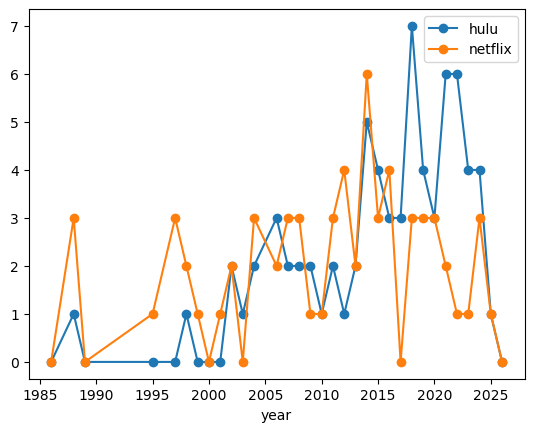

In [150]:
# Quick line graph to spot the exact takeoff year
df.groupby('year')[['hulu', 'netflix']].sum().plot(kind='line', marker='o')

Looking at both the chart and graph above, 2014 appears to be the year where Hulu and Netflix took off with landing contracts to stream animes on their platform.

In [195]:
# 1. Get the yearly totals
yearly_totals = df.groupby('year')[['hulu', 'netflix']].sum()

# 2. Filter for your window (2010 to 2015)
window = yearly_totals.loc[2010:2015]

# 3. Calculate the year-over-year percentage growth
growth_rate = window.pct_change() * 100

print('Relative Change:')
print(growth_rate)

Relative Change:
       hulu     netflix
year                   
2010    NaN         NaN
2011  100.0  200.000000
2012  -50.0   33.333333
2013  100.0  -50.000000
2014  150.0  200.000000
2015  -20.0  -50.000000


In [196]:
print('Raw Counts:')
print(yearly_totals.loc[2010:2015])

Raw Counts:
      hulu  netflix
year               
2010     1        1
2011     2        3
2012     1        4
2013     2        2
2014     5        6
2015     4        3


There was seemingly a large postive growth rate in 2014 for both Hulu and Netflix like we saw in the graph above, but the very next year there a negative percentage change meaning that Netflix and Hulu were either actively losing licensing contracts or they were dropping ttitles faster than they were adding them in 2015.

It is a good idea to look at the relative change (percentages) and the absolute change (raw counts) before drawing any final conclusions because if you look at the raw counts for instance, Netflix had 6 titles in 2014 and then dropped down to only 3 anime titles which is half the titles but the growth rate in the Relative Change table obove looked like Netflix had this massive growth of 200% but it was not that large in reality.

### Question 2: Which platform has the most active animes that are still airing or in production?

In [200]:
# Filter the DataFrame for active statuses
active_anime = df[df['status'].isin(['Currently Airing', 'Ongoing'])]

# Sum the platform columns on this filtered dataset
active_counts = active_anime[platforms].sum().sort_values(ascending=False)

print('Platforms and their number of active animes still airing or in production:')
print(active_counts)

Platforms and their number of active animes still airing or in production:
crunchyroll     9
hulu            4
netflix         2
funimation      1
disney_plus     1
amazon_prime    0
hbo_max         0
hidive          0
pokemon_tv      0
dtype: int64


<Axes: >

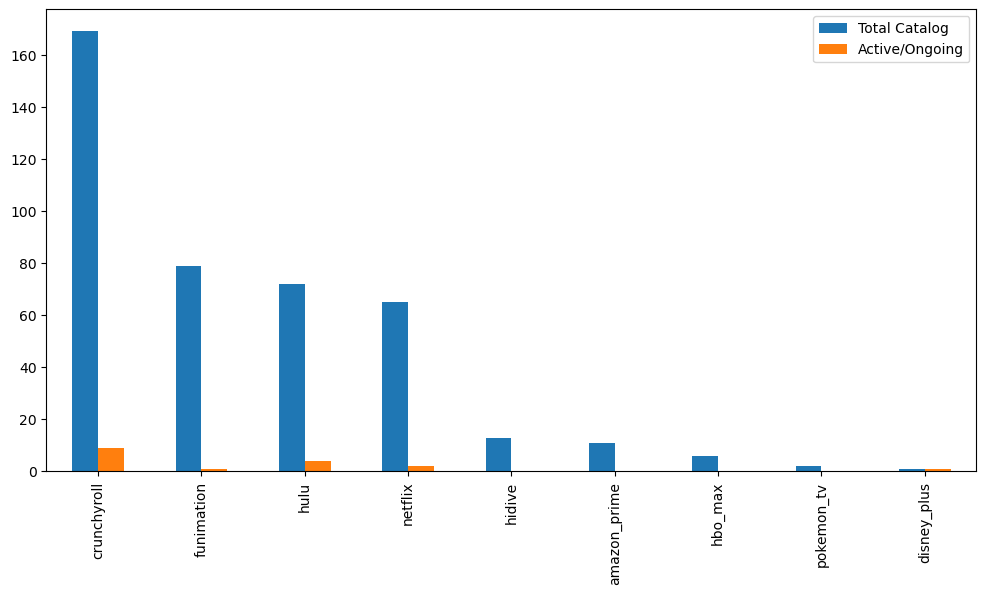

In [201]:
# Get total counts
total_counts = df[platforms].sum()

# Get active counts (using the filtered dataframe from earlier)
active_counts = active_anime[platforms].sum()

# Combine them into a single DataFrame for plotting
comparison_df = pd.DataFrame({
    'Total Catalog': total_counts,
    'Active/Ongoing': active_counts
}).sort_values(by='Total Catalog', ascending=False)

# Plot a side-by-side bar chart
comparison_df.plot(kind='bar', figsize=(12, 6))

This is interesting to see that Crunchyroll is still actively producing anime shows which makes sense when they shows that have episodes released weekly vs Netflix doesn't really do that. 

### Question 3: Which genre seems to be the most popular overall?

In [205]:
# Define the list of your genre columns
genres = ['genre_action', 'genre_adventure', 'genre_comedy', 'genre_crime', 'genre_cyberpunk',
'genre_demons', 'genre_drama', 'genre_ecchi', 'genre_fantasy', 'genre_game', 'genre_historical', 'genre_horror',
'genre_josei', 'genre_magic', 'genre_martial_arts', 'genre_mecha', 'genre_military', 'genre_music', 'genre_mystery',
'genre_parody', 'genre_psychological', 'genre_romance', 'genre_samurai', 'genre_school', 'genre_sci-fi', 'genre_seinen',
'genre_shoujo', 'genre_shounen', 'genre_slice_of_life', 'genre_space', 'genre_sports', 'genre_super_power', 'genre_superhero',
'genre_supernatural', 'genre_superpower', 'genre_thriller', 'genre_western']

# Sum the columns and sort from highest to lowest
genre_total_popularity = df[genres].T.dot(df['popularity']).sort_values(ascending=False)

# View the results
print("Total popularity by genre")
print(genre_total_popularity)

Total popularity by genre
genre_action           212946479
genre_adventure        138803071
genre_fantasy          136538429
genre_supernatural     121995538
genre_drama            120230107
genre_comedy           107360809
genre_super_power       45220813
genre_psychological     43032093
genre_mystery           33970980
genre_horror            33907526
genre_sci-fi            33174451
genre_romance           32517897
genre_martial_arts      22771097
genre_school            22226384
genre_military          19320981
genre_demons            19311600
genre_historical        19175057
genre_thriller          18551230
genre_slice_of_life     18133332
genre_parody            12730851
genre_shounen           11500000
genre_superhero          9012333
genre_superpower         9012333
genre_sports             8747899
genre_mecha              8189505
genre_shoujo             7800000
genre_music              5887654
genre_game               5600118
genre_magic              4209875
genre_ecchi      

In [206]:
# Get total popularity per genre
total_pop = df[genres].T.dot(df['popularity'])

# Get the total number of shows per genre
raw_counts = df[genres].sum()

# Calculate the average popularity per show in each genre
average_genre_popularity = (total_pop / raw_counts).round().sort_values(ascending=False)

print("Average popularity of shows in each genre")
print(average_genre_popularity)

Average popularity of shows in each genre
genre_shoujo           3900000.0
genre_martial_arts     3795183.0
genre_cyberpunk        3500000.0
genre_superpower       3004111.0
genre_superhero        3004111.0
genre_josei            3000000.0
genre_shounen          2875000.0
genre_super_power      2153372.0
genre_demons           2145733.0
genre_horror           1883751.0
genre_parody           1818693.0
genre_crime            1800000.0
genre_supernatural     1768051.0
genre_romance          1711468.0
genre_adventure        1692720.0
genre_fantasy          1665103.0
genre_drama            1646988.0
genre_action           1543090.0
genre_comedy           1533726.0
genre_slice_of_life    1511111.0
genre_military         1486229.0
genre_historical       1475004.0
genre_magic            1403292.0
genre_psychological    1388132.0
genre_thriller         1325088.0
genre_mystery          1306576.0
genre_school           1234799.0
genre_music            1177531.0
genre_samurai          1150000.0
g

The Total Popularity data might tell a Streaming Platform where to spend their big budget to keep the massive, casual user base happy.

However, the Average Popularity data might tell them which niche communities have the highest concentration of die-hard fans. If one of the platforms greenlights a new Shoujo, Martial Arts, or Cyberpunk show, they know that community will flood the platform to watch it.

### Question 4: Which genre has been the most popular over the past 10 years vs the most popoular this past year?

In [208]:
# Define time window
past_10_years = df[df['year'].between(2016, 2026)]
past_year = df[df['year'] == 2025]

# Calculate the top total popularity for the past 10 years
top_genres_10yr = past_10_years[genres].T.dot(past_10_years['popularity']).sort_values(ascending=False)

# Calculate the top total popularity for this past year
top_genres_1yr = past_year[genres].T.dot(past_year['popularity']).sort_values(ascending=False)

print("--- Top 5 Genres Over the Past 10 Years (2016-2026) ---")
print(top_genres_10yr.head(5))

print("\n--- Top 5 Genres This Past Year (2025) ---")
print(top_genres_1yr.head(5))

--- Top 5 Genres Over the Past 10 Years (2016-2026) ---
genre_action          106246391
genre_supernatural     66701715
genre_drama            62787520
genre_fantasy          61508906
genre_adventure        58116661
dtype: int64

--- Top 5 Genres This Past Year (2025) ---
genre_action          2444443
genre_demons          1456789
genre_adventure       1456789
genre_supernatural    1456789
genre_historical      1456789
dtype: int64


Genres like supernatural, adventure, and action have been relevant for the past 10 years and still are vs the demons genre became very populast last year probably relevant to animes like Demon Slayer. Let's find out!

### Question 5: Which animes have the word "demon" in the synopsis and were also streaming in the year 2025? Since genre_demons appeared in the top 5 genres in 2025 based on Question 4 above, we can see which anime titles contributed to that ranking.

In [210]:
# Make sure your synopsis column doesn't have missing values
df['synopsis'] = df['synopsis'].fillna('')

# Filter for rows from 2025 that contain the word "demon" (case-insensitive)
demon_2025_df = df[(df['year'] == 2025) & (df['synopsis'].str.contains('demon', case=False))]

# Get the count and the list of titles
count = len(demon_2025_df)
titles = demon_2025_df['title'].tolist()

print(f"Number of 2025 titles with 'demon' in the synopsis: {count}")
print("\nTitles:")
for title in titles:
    print(f"- {title}")

Number of 2025 titles with 'demon' in the synopsis: 1

Titles:
- Demon Slayer: Kimetsu no Yaiba – The Movie: Infinity Castle


As guessed, Demon Slayer: Kimetsu no Yaiba – The Movie: Infinity Castle was released in 2025 and appeared in the top genre in 2025.

### Question 6: Whiche anime has the most episodes and which has the best ratings?

In [211]:
# Find the anime with the absolute most episodes
most_episodes_anime = df.loc[df['episodes'].idxmax(), 'title']
max_episodes_count = df['episodes'].max()

# Find the anime with the absolute highest rating
best_rated_anime = df.loc[df['rating'].idxmax(), 'title']
max_rating_score = df['rating'].max()

print(f"Most Episodes: '{most_episodes_anime}' with {max_episodes_count} episodes.")
print(f"Highest Rated: '{best_rated_anime}' with a rating of {max_rating_score}.")

Most Episodes: 'One Piece' with 1136 episodes.
Highest Rated: 'Attack on Titan: The Final Season Part 2' with a rating of 9.3.


The most episodes in an Anime show is One Piece coming in at 1136 episodes which is not too suprising! The highest rated anime is 'Attack on Titan: The Final Season Part 2' with a rating of 9.3. A question we will look at next is whether Attack on Titan: The Final Season part 2 is also the most popular.

### Question 6a: Is the anime with the best ratings also the most popular?

In [212]:
 # Sort by popularity descending and reset the index so we can see the rank number (1st, 2nd, 3rd...)
popularity_ranking = df.sort_values(by='popularity', ascending=False).reset_index()

# Find the row where our highest-rated show lives
aot_rank = popularity_ranking[popularity_ranking['title'] == best_rated_anime].index[0] + 1

print(f"Attack on Titan's Popularity Rank: #{aot_rank}")

Attack on Titan's Popularity Rank: #43


In [213]:
# Calculate the statistical correlation between ratings and popularity
correlation = df['rating'].corr(df['popularity'])

print(f"Correlation between Rating and Popularity: {correlation:.2f}")

Correlation between Rating and Popularity: 0.16


We observed that Attack on Titan: The Final Season Part 2 is not the most popular anime as it comes in at a ranking of #43 in popularity. After running a correlation between ratings and popularity, we can see that there is not a strong correlation at 0.16. Therefore, an anime having a high rating does not guarantee it will be popular, and a highly popular anime isn't necessarily a critical masterpiece.

Let's also confirm this by looking at the top 5 highest rated and top 5 most popular animes side-by-side to see if they match up.

In [215]:
# Get the Top 5 Highest Rated vs Top 5 Most Popular side-by-side
top_5_rated = df.sort_values(by='rating', ascending=False)['title'].head(5).values
top_5_popular = df.sort_values(by='popularity', ascending=False)['title'].head(5).values

# Create a clean comparison dataframe
showdown_df = pd.DataFrame({
    'Top 5 Highest Rated': top_5_rated,
    'Top 5 Most Popular': top_5_popular
})

print("--- The Popularity vs. Rating Showdown ---")
print(showdown_df)

--- The Popularity vs. Rating Showdown ---
                        Top 5 Highest Rated                 Top 5 Most Popular
0  Attack on Titan: The Final Season Part 2                      Dragon Ball Z
1         Attack on Titan: The Final Season  Pokemon - Season 1: Indigo League
2                     Vinland Saga Season 2                             Arcane
3                        Mob Psycho 100 III              Oshi no Ko - Season 1
4       Fruits Basket: The Final - Season 3   The Seven Deadly Sins - Season 1


And we can confirm that the top 5 highest rated animes are completely different from the top 5 most popular animes.

### Question 7: Which 5 animes have the most seasons?

In [216]:
# Extract everything before the word " Season" to get the clean franchise name
df['franchise'] = df['title'].str.split('(?i)\s+Season').str[0]

# Group by the base franchise name, find the max season, and sort
top_franchises = df.groupby('franchise')['season_num'].max().sort_values(ascending=False).head(5)

# Reset the index to make it look like a clean table
top_franchises_df = top_franchises.reset_index()
top_franchises_df.columns = ['Franchise', 'Highest Season Reached']

print("--- Top 5 Franchises with the Most Seasons ---")
print(top_franchises_df.to_string(index=False))

--- Top 5 Franchises with the Most Seasons ---
                              Franchise  Highest Season Reached
                       My Hero Academia                       7
                               Overlord                       4
That Time I Got Reincarnated as a Slime                       3
             Fruits Basket: The Final -                       3
                          One Punch Man                       3


My Hero Academia had the highest number of seasons coming in at 7, which I will admit this is my favorite anime. A future question might be to see if these shows fall into one of the top 5 genres over the past 10 years.

## Conclusion & Key Takeaways

After exploring the dataset through these 7 questions, three major analytical insights stand out regarding the anime streaming landscape and viewer behavior:

### 1. The Disconnect Between Mass Popularity and Critical Acclaim
One of the most significant findings is that **critical acclaim does not drive mass popularity (and vice versa).** * We calculated a very weak statistical correlation of **0.16** between ratings and popularity.
* This was visually proven by the complete lack of overlap in The Popularity vs. Rating Showdown. Mainstream, nostalgic giants like *Dragon Ball Z* and *Pokémon* command the most eyes, while shows like *Attack on Titan* and *Vinland Saga* captured the highest critical scores.
  
### 2. Mainstream vs. Niche Fandoms
By expanding our genre analysis to compare **Total Popularity** against **Average Popularity**, we uncovered two distinct audience dynamics:
* **Mainstream Favorites:** Genres like *Action*, *Adventure*, and *Fantasy* accumulate the highest overall footprint simply due to volume and broad appeal.
* **Niche Favorites:** Genres like *Shoujo*, *Martial Arts*, and *Cyberpunk* have a passionate fanbase that drives the *average views* to the top of the dataset.

### 3. Micro-Trends Heavily Distort Macro-Data
Our timeline and text-pattern analysis proved how a single show can completely shift market data. 
* In our 2025 analysis, a massive multi-column tie occurred where *Demons*, *Historical*, *Supernatural*, and *Adventure* all shared an identical popularity score.
* By using string matching on the synopses, we unmasked why the Demons genre appeared in top 5 genres in 2025 but not in the past decade. The highly anticipated 2025 release of *Demon Slayer: Kimetsu no Yaiba – The Movie: Infinity Castle*. A single global movie can completely warp an entire year's genre trends.

### Technical Achievements in this Notebook:
* **Feature Engineering:** Extracted complex seasonal data from raw text strings in the Title column using Regular Expressions (`Regex`) to isolate clean franchise names and separated the original genre column and streaming platforms into one-hot encoded variables.
* **Matrix Operations:** Utilized matrix transposition (`.T`) and weighted dot products (`.dot()`) to cleanly calculate popularity distributions across one-hot encoded variables.
* **Statistical Validation:** Applied Pearson correlation coefficients to test and disprove assumptions regarding ratings vs. popularity.

### 🚀 Future Work & Next Steps

If expanded further, this project could be taken to the next level by exploring the following areas:

1. **Advanced Text Mining & Sentiment Analysis:** Move beyond basic keyword matching (`.str.contains()`) to run full Natural Language Processing (NLP) on the synopses. This would allow us to cluster shows by emotional themes, tone, and complex tropes rather than relying solely on pre-defined genre tags.
2. **Predictive Modeling for Show Success:** Use the engineered features (like franchise season counts, studio/platform exclusivity, and text embeddings from the synopses) to build a machine learning model that predicts an upcoming anime’s popularity or rating before it airs.
3. **Temporal Analysis of Genre Lifespans:** Track the exact lifespan of genre trends over a larger 20-year window to mathematically model how long a genre cycle lasts (e.g., how many years does a *Demons* or *Slice of Life* craze dominate the market before audience fatigue sets in?).